In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv")

In [3]:
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


In [4]:
X = data.x
y = data.y

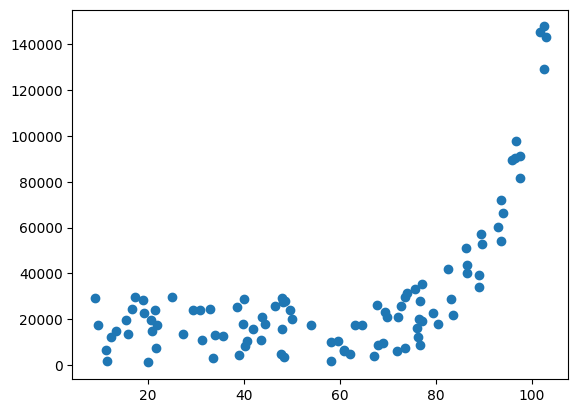

In [5]:
plt.scatter(X, y)

In [6]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression()

In [7]:
X = pd.DataFrame(X)

In [8]:
linear.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


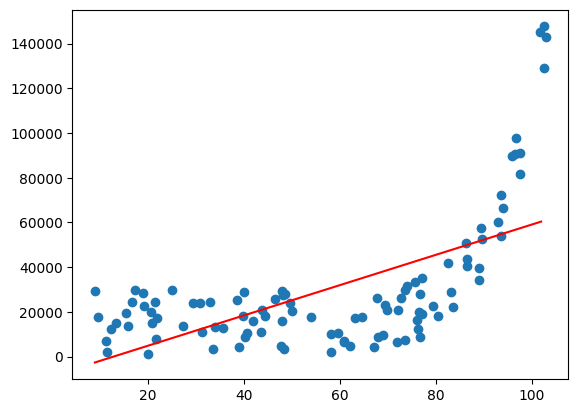

In [9]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

In [10]:
linear.score(X, y)

0.37467360318911636

In [11]:
from sklearn.preprocessing import PolynomialFeatures

In [12]:
transformation = PolynomialFeatures(degree=2)

In [13]:
transformation.fit(X)

,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [14]:
X_2 = transformation.transform(X)

In [15]:
X_2.shape
X_2[:5]

array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

In [16]:
poly_2d = LinearRegression().fit(X_2, y)

In [17]:
xx_2d = transformation.transform(pd.DataFrame(xx))

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


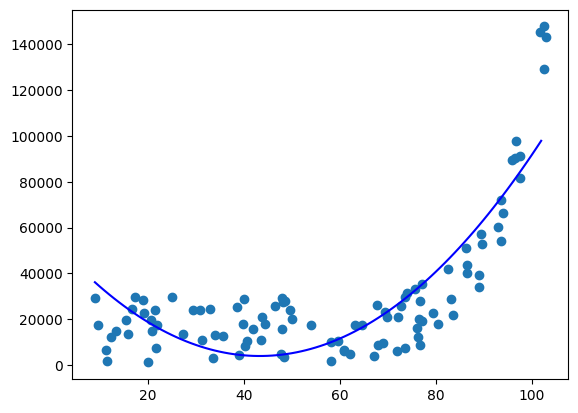

In [18]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='b')

In [19]:
poly_2d.score(X_2, y)

0.7359753787024843

In [20]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)

In [21]:
y = data.y
X = data.drop(["y"], axis=1)

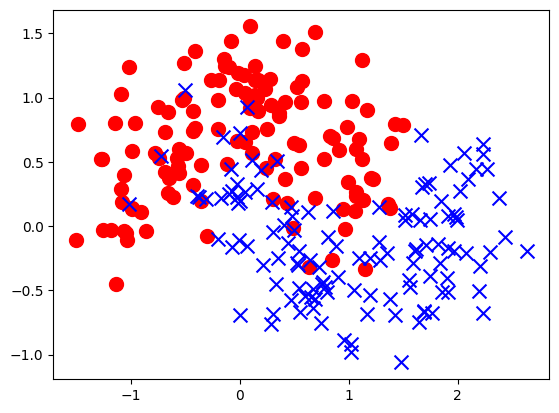

In [22]:
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
logistic = LogisticRegression().fit(X, y)

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_35311/739733186.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(X.min()[0], X.max()[0]+0.1, 0.01),
/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_35311/739733186.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(X.min()[1], X.max()[1]+0.1, 0.01))
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


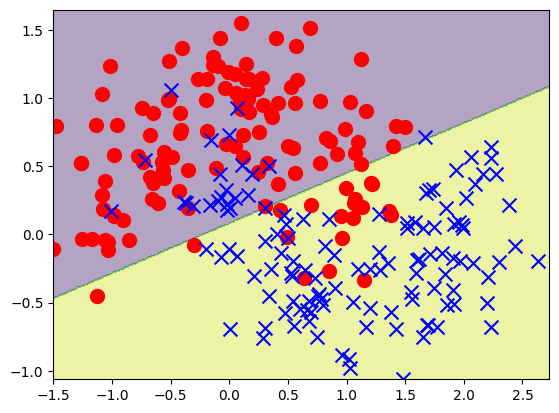

In [25]:
xx, yy = np.meshgrid(
    np.arange(X.min()[0], X.max()[0]+0.1, 0.01),
    np.arange(X.min()[1], X.max()[1]+0.1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [26]:
logistic.score(X, y)

0.832

In [27]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)

In [28]:
X_3.shape

(250, 9)

In [29]:
class_3 = LogisticRegression().fit(X_3, y)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


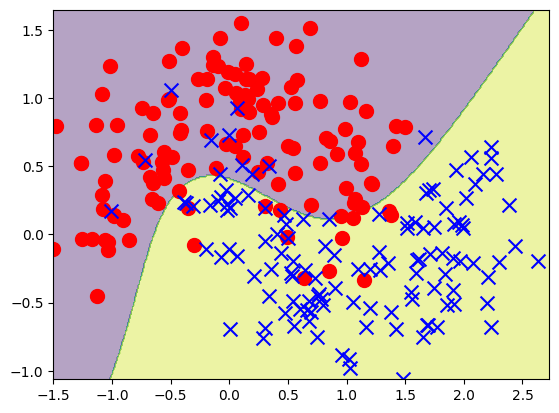

In [30]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [31]:
class_3.score(X_3, y)

0.9

In [32]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

In [33]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [34]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

In [35]:
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

In [36]:
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

0.6997471890109157

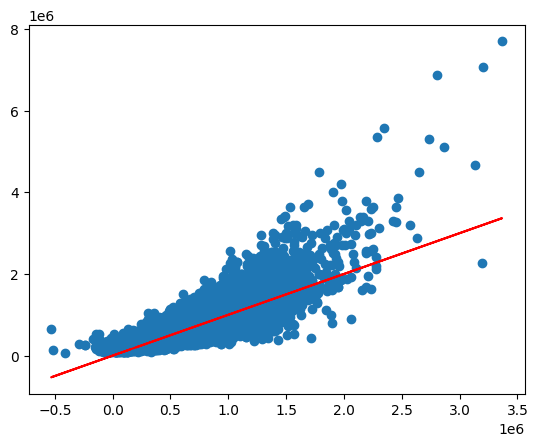

In [37]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

In [38]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)

In [39]:
X_3_kc_prices.shape

(21613, 1330)

In [40]:
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

0.8326020796592739

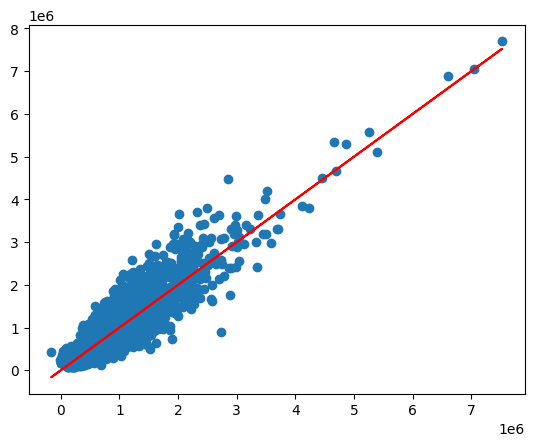

In [41]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

## Практическая работа

### 1. Замер времени

In [42]:
import time

In [43]:
start_time = time.time()
linear = LinearRegression().fit(X, y)
linear_time = time.time() - start_time
print(f"Время обучения линейной регрессии: {linear_time:.4f} секунд")
print(f"Точность (R2): {linear.score(X, y):.4f}\n")

Время обучения линейной регрессии: 0.0007 секунд
Точность (R2): 0.5164



In [44]:
start_time = time.time()
transformation = PolynomialFeatures(degree=2)
X_2 = transformation.fit_transform(X)
poly_2d = LinearRegression().fit(X_2, y)
poly_time = time.time() - start_time
print(f"Время обучения полиномиальной регрессии (степень 2): {poly_time:.4f} секунд")
print(f"Точность (R2): {poly_2d.score(X_2, y):.4f}")

Время обучения полиномиальной регрессии (степень 2): 0.0007 секунд
Точность (R2): 0.5197


In [45]:
start_time = time.time()
logistic = LogisticRegression(max_iter=10000).fit(X, y)
logistic_time = time.time() - start_time
print(f"Время обучения логистической регрессии: {logistic_time:.4f} секунд")
print(f"Точность: {logistic.score(X, y):.4f}\n")

Время обучения логистической регрессии: 0.0018 секунд
Точность: 0.8320



In [46]:
start_time = time.time()
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)
class_3 = LogisticRegression().fit(X_3, y)
poly_class_time = time.time() - start_time
print(f"Время обучения полиномиальной классификации (степень 3): {poly_class_time:.4f} секунд")
print(f"Точность: {class_3.score(X_3, y):.4f}")

Время обучения полиномиальной классификации (степень 3): 0.0024 секунд
Точность: 0.9000


In [47]:
start_time = time.time()
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
linear_kc_time = time.time() - start_time
print(f"Время обучения линейной регрессии (King County): {linear_kc_time:.4f} секунд")
print(f"Точность (R2): {reg_kc_multiple.score(X_kc_prices, y_kc_prices):.4f}\n")

Время обучения линейной регрессии (King County): 0.0036 секунд
Точность (R2): 0.6997



In [48]:
start_time = time.time()
poly_features_kc_prices = PolynomialFeatures(degree=2)
X_2_kc_prices = poly_features_kc_prices.fit_transform(X_kc_prices)
reg_poly2_kc = LinearRegression().fit(X_2_kc_prices, y_kc_prices)
poly_kc_time = time.time() - start_time
print(f"Время обучения полиномиальной регрессии (степень 2, King County): {poly_kc_time:.4f} секунд")
print(f"Точность (R2): {reg_poly2_kc.score(X_2_kc_prices, y_kc_prices):.4f}")

Время обучения полиномиальной регрессии (степень 2, King County): 0.0601 секунд
Точность (R2): 0.8084


### 2. Строим и сравниваем 5, 10, 100 порядки

In [119]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv")
X = data[['x']]
y = data['y']

In [120]:
from sklearn.preprocessing import StandardScaler

In [121]:
results_reg = []

In [122]:
for num_poly in [5, 10, 100]:
    start_time = time.time()
    poly = PolynomialFeatures(num_poly)
    X_transform = poly.fit_transform(X)
    poly_transform = LinearRegression().fit(X_transform, y)
    poly_time = time.time() - start_time
    r2 = poly_transform.score(X_transform, y)
    results_reg.append([num_poly, r2, poly_time])
    print(f"Полином степени {num_poly} имеет R2 = {poly_transform.score(X_transform, y)} и время = {poly_time}")

Полином степени 5 имеет R2 = 0.921747806044701 и время = 0.0032889842987060547
Полином степени 10 имеет R2 = 0.9222468251462039 и время = 0.0025489330291748047
Полином степени 100 имеет R2 = 0.792462000446692 и время = 0.003509998321533203


### 3. Для другого датасета классификации

In [123]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)
y = data.y
X = data.drop(["y"], axis=1)

In [124]:
results = []

In [125]:
for num_poly in [4, 5, 10]:
    start_time = time.time()
    poly = PolynomialFeatures(num_poly, include_bias=False)
    X_transform = poly.fit_transform(X)
    poly_transform = LogisticRegression(max_iter=1000).fit(X_transform, y)
    poly_time = time.time() - start_time
    accuracy = poly_transform.score(X_transform, y)
    results.append([num_poly, accuracy, poly_time])
    print(f"Полином степени {num_poly} имеет accuracy = {poly_transform.score(X_transform, y)} и время = {poly_time}")

Полином степени 4 имеет accuracy = 0.912 и время = 0.009221076965332031
Полином степени 5 имеет accuracy = 0.916 и время = 0.005604267120361328
Полином степени 10 имеет accuracy = 0.924 и время = 0.005940914154052734


### 4. Таблица эффективности моделей

In [126]:
df_reg = pd.DataFrame(results_reg, columns=['Степень', 'R2', 'Время (сек)'])
df_clf = pd.DataFrame(results, columns=['Степень', 'Accuracy', 'Время (сек)'])

In [128]:
df_reg, df_clf

(   Степень        R2  Время (сек)
 0        5  0.921748     0.003289
 1       10  0.922247     0.002549
 2      100  0.792462     0.003510,
    Степень  Accuracy  Время (сек)
 0        4     0.912     0.009221
 1        5     0.916     0.005604
 2       10     0.924     0.005941)

Вывод

- **Степени 5-10** дают наилучший баланс точности и времени обучения
- **Степень 100** приводит к переобучению и снижению качества
- **Рекомендуется** использовать степени полинома не выше 10, так как дальнейшее увеличение нецелесообразно из-за роста вычислительной сложности и риска переобучения

### 5. Коэффициенты модели в задаче продажи домов

In [129]:
data_kc = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
y_kc = data_kc.price
X_kc = data_kc.drop(["id", "date", "price"], axis=1)

In [130]:
model = LinearRegression().fit(X_kc, y_kc)

In [133]:
features = model.feature_names_in_
coefs = model.coef_

In [134]:
coef_df = pd.DataFrame({'Атрибут': features, 'Коэффициент': coefs})

In [144]:
coef_df.iloc[coef_df['Коэффициент'].abs().sort_values(ascending=False).index]

,Атрибут,Коэффициент
14,lat,602748.226449
5,waterfront,582960.458423
15,long,-214729.828253
8,grade,95890.445151
6,view,52870.942384
1,bathrooms,41144.278533
0,bedrooms,-35766.541444
7,condition,26385.649139
4,floors,6689.550115
11,yr_built,-2620.223211


**Наиболее важные атрибуты (положительное влияние):**
- **lat** (широта) — самый значимый фактор, определяющий стоимость дома
- **waterfront** (наличие вида на воду) — увеличивает цену на ~583 тыс. долл.
- **grade** (качество дома) — важный показатель
- **view** (обзор) и **bathrooms** (количество ванных)

**Наименее важные атрибуты:**
- **sqft_lot15**, **sqft_lot** (площадь участка) — практически не влияют на цену

**Отрицательное влияние:**
- **long** (долгота) — снижает стоимость
- **bedrooms** (спальни) — увеличение количества спален парадоксально снижает цену (возможно, из-за корреляции с другими факторами)
- **yr_built** (год постройки) — старые дома дешевле

### 6. Полиномиальная модель 

In [152]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_kc)
model_poly = LinearRegression().fit(X_poly, y_kc)

In [153]:
feature_names = poly.get_feature_names_out(X_kc.columns)
coefs_poly = model_poly.coef_

In [154]:
coef_poly_df = pd.DataFrame({'Признак': feature_names, 'Коэффициент': coefs_poly})

In [155]:
coef_poly_df = coef_poly_df.iloc[coef_poly_df['Коэффициент'].abs().sort_values(ascending=False).index]

In [156]:
print(coef_poly_df.head(15))

                 Признак   Коэффициент
12          yr_renovated  31787.760850
39      bathrooms floors -24315.043387
43       bathrooms grade  18612.372510
84              floors^2  17328.026949
10         sqft_basement -16245.869520
16         sqft_living15  14786.340518
9             sqft_above  14208.791189
87      floors condition  14188.112835
22       bedrooms floors  13689.728257
88          floors grade  10712.666808
42   bathrooms condition  -9596.716994
134              grade^2   8206.870138
165        yr_built long   7360.532375
111               view^2   7115.387133
41        bathrooms view   5861.684813


**Ключевые признаки:**
- **yr_renovated** (год реновации) — самый важный признак, определяет стоимость
- **Взаимодействия** (bathrooms×grade, bedrooms×floors) показывают совместное влияние факторов
- **Квадраты** (floors², grade²) указывают на нелинейную зависимость

**Важные взаимодействия:**
- bathrooms×grade — сочетание ванных и качества дома
- bathrooms×floors — влияние ванных на разных этажах

## Доп задания

### 1. Таблица сравнения полиномов и разделение датасета

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [53]:
X_train.shape, X_test.shape

((187, 2), (63, 2))

In [54]:
results = []

for degree in range(1, 6):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_score = model.score(X_train_poly, y_train)
    test_score = model.score(X_test_poly, y_test)

    results.append([degree, train_score, test_score])

    print(f"Степень {degree}: Train R2 = {train_score:.4f}, Test R2 = {test_score:.4f}")

Степень 1: Train R2 = 0.4890, Test R2 = 0.5955
Степень 2: Train R2 = 0.4970, Test R2 = 0.5798
Степень 3: Train R2 = 0.6080, Test R2 = 0.6024
Степень 4: Train R2 = 0.6185, Test R2 = 0.5593
Степень 5: Train R2 = 0.6821, Test R2 = 0.5588


In [55]:
results_df = pd.DataFrame(results, columns=['Степень', 'Train R2', 'Test R2'])
print(results_df)

best = results_df.loc[results_df['Test R2'].idxmax()]
print(f"\nЛучшая степень: {int(best['Степень'])} с Test R2 = {best['Test R2']:.4f}")

   Степень  Train R2   Test R2
0        1  0.489038  0.595475
1        2  0.496959  0.579787
2        3  0.607964  0.602378
3        4  0.618483  0.559303
4        5  0.682053  0.558810

Лучшая степень: 3 с Test R2 = 0.6024


### 2. Конвейер и поиск полинома

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [57]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('clf', LogisticRegression(max_iter=1000))
])

In [58]:
for degree in [1, 2, 3, 4, 5]:
    pipeline.set_params(poly__degree=degree)
    pipeline.fit(X_train, y_train)
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    print(f"Степень {degree}: Train = {train_score:.4f}, Test = {test_score:.4f}")

Степень 1: Train = 0.8128, Test = 0.8889
Степень 2: Train = 0.8182, Test = 0.8730
Степень 3: Train = 0.9037, Test = 0.8889
Степень 4: Train = 0.9198, Test = 0.8889
Степень 5: Train = 0.9251, Test = 0.8889


### 3. Новый датасет

In [59]:
from sklearn.datasets import load_digits

In [60]:
digits = load_digits()
X, y = digits.data, digits.target

In [61]:
X.shape, y.shape

((1797, 64), (1797,))

In [62]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
results = []

In [65]:
linear_model = LogisticRegression(max_iter=1000, random_state=42)
linear_model.fit(X_train, y_train)
linear_score = linear_model.score(X_test, y_test)
print(f"Точность на тесте: {linear_score:.4f}")

Точность на тесте: 0.9750


In [66]:
for degree in [2, 3]:

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LogisticRegression(max_iter=2000, random_state=42)
    model.fit(X_train_poly, y_train)

    train_score = model.score(X_train_poly, y_train)
    test_score = model.score(X_test_poly, y_test)

    print(f"Полиномиальная модель (degree={degree}):")
    print(f"Точность на обучении: {train_score:.4f}")
    print(f"Точность на тесте: {test_score:.4f}\n")

Полиномиальная модель (degree=2):
Точность на обучении: 1.0000
Точность на тесте: 0.9750

Полиномиальная модель (degree=3):
Точность на обучении: 1.0000
Точность на тесте: 0.9806

